In [11]:
import duckdb
import pandas as pd
from networks.inflammation_network import to_coral
from networks.inflammation_network import build_dataloaders
from networks.inflammation_network import InflammationModel

con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT 
                        p.row_id,
                        any_value(pid) as pid, 
                        any_value(value) as value,
                        any_value(fractions) as fractions,
                        any_value(boundaries) as boundaries,
                        any_value(albumin) as albumin,
                        any_value(antitrypsin) as antitrypsin,
                        any_value(orosomukoid) as orosomukoid,
                        any_value(haptoglobin) as haptoglobin,
                        any_value(crp) as crp,
                        any_value(igg) as igg,
                        any_value(iga) as iga,
                        any_value(igm) as igm,
                        list(c.comment_nr) as comment_nr,
                        any_value(age) as age,
                        any_value(sign) as sign,
                        any_value(set) as set,
                    FROM protein_data p
                    LEFT JOIN comment_precences c 
                        ON p.row_id = c.row_id
                    WHERE p.row_id IN (
                        SELECT row_id FROM comment_precences 
                        WHERE comment_nr BETWEEN 16 AND 27
                    )
                    GROUP BY p.row_id
                """).df()


con.close()

def get_inflammation_comment(comments):
    for i in range(16, 28):
        if i in comments:
            return i
    return None


df['inflammation_comment'] = df['comment_nr'].apply(get_inflammation_comment)
df = df[df['inflammation_comment'].notna()]


df['label'] = df['inflammation_comment'].apply(to_coral)
train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

print(df['label'].value_counts().sort_index())

train_dl, val_dl, test_dl = build_dataloaders(train_rows, val_rows, test_rows)
inflammation_model = InflammationModel()
#inflammation_model.retrain(train_dl,val_dl)

label
[0, 0, 0, 0, 0, 0, 0, 0]    78286
[1, 0, 0, 0, 0, 0, 0, 0]     3470
[1, 1, 0, 0, 0, 0, 0, 0]    10727
[1, 1, 1, 0, 0, 0, 0, 0]    47563
[1, 1, 1, 1, 0, 0, 0, 0]     7249
[1, 1, 1, 1, 1, 0, 0, 0]     4799
[1, 1, 1, 1, 1, 1, 0, 0]     1558
[1, 1, 1, 1, 1, 1, 1, 0]     5927
[1, 1, 1, 1, 1, 1, 1, 1]      235
Name: count, dtype: int64


MAE:          0.281
Exakt rätt:   80.3%
Inom ±1 grad: 93.2%
Inom ±2 grad: 98.4%
The bias is: -0.00014586676843464375
inflammation level: 0 | predicted amount within 1 unit: 3791 | true amount within 1 unit: 3762
inflammation level: 1 | predicted amount within 1 unit: 4030 | true amount within 1 unit: 174
inflammation level: 2 | predicted amount within 1 unit: 2404 | true amount within 1 unit: 456
inflammation level: 3 | predicted amount within 1 unit: 2828 | true amount within 1 unit: 2274
inflammation level: 4 | predicted amount within 1 unit: 968 | true amount within 1 unit: 326
inflammation level: 5 | predicted amount within 1 unit: 392 | true amount within 1 unit: 219
inflammation level: 6 | predicted amount within 1 unit: 350 | true amount within 1 unit: 55
inflammation level: 7 | predicted amount within 1 unit: 312 | true amount within 1 unit: 288
inflammation level: 8 | predicted amount within 1 unit: 49 | true amount within 1 unit: 8


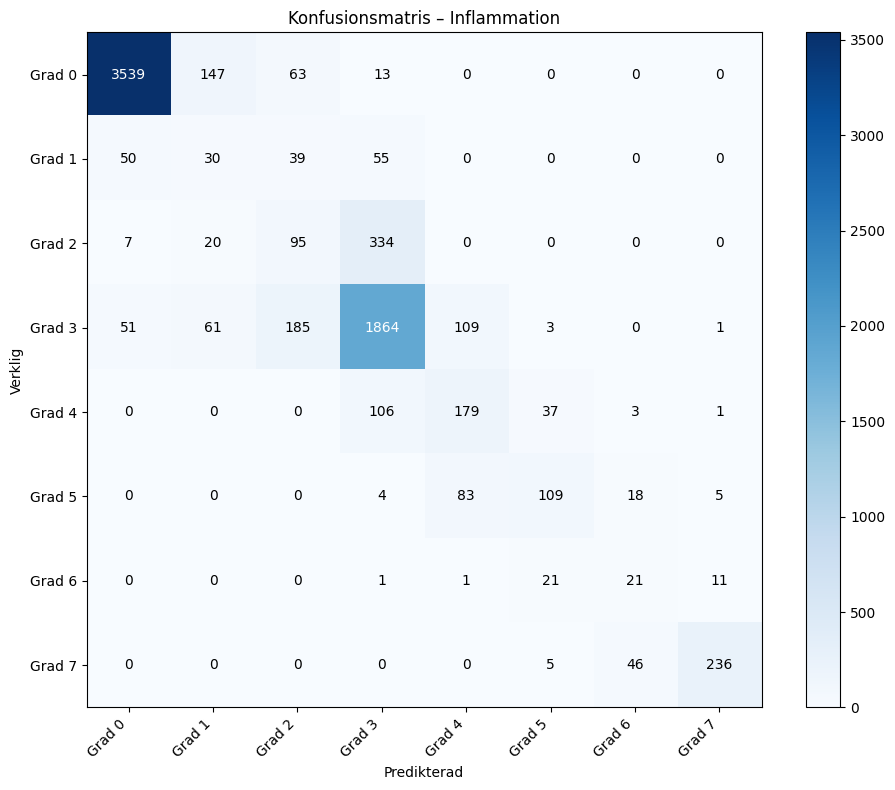

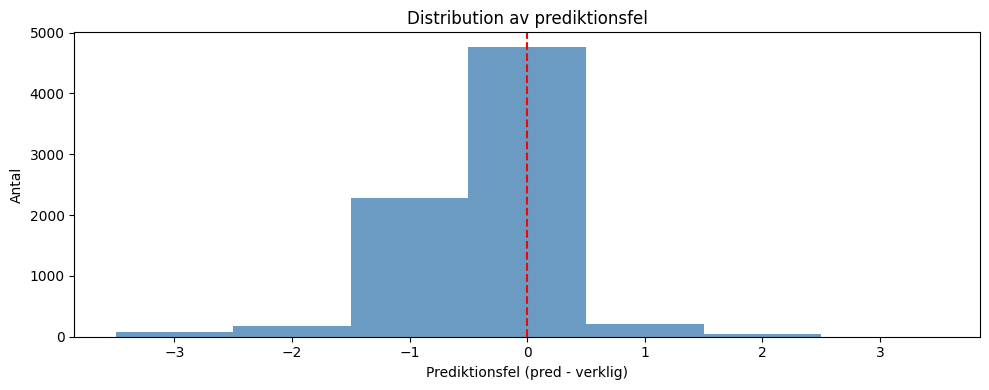

    inflammation_comment  severity_from_comment
0                     17                      3
1                     20                      0
2                     22                      3
3                     21                      2
4                     20                      0
5                     22                      3
6                     20                      0
7                     17                      3
8                     19                      1
9                     22                      3
10                    20                      0
11                    20                      0
12                    22                      3
13                    23                      4
14                    22                      3
15                    20                      0
16                    22                      3
17                    20                      0
18                    19                      1
19                    18                

,row_id,pid,value,fractions,boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm,comment_nr,age,sign,set,inflammation_comment,label,severity_from_comment
0,132601,73717400,"[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 3, ...","[59.93461206468517, 3.913345708152867, 12.0196...","[78, 91, 120, 130, 145, 167, 186, 199, 210, 21...",42.0,1.70,1.12,1.89,4.5,9.63,2.02,0.74,"[807, 17, 90, 200, 828]",63.750000,mla,train,17,"[1, 1, 1, 0, 0, 0, 0, 0]",3
1,132661,73735660,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, ...","[63.49811665067964, 3.776836752996592, 9.45184...","[79, 93, 120, 133, 147, 169, 192, 201, 207, 26...",48.0,1.65,0.80,1.30,1.6,10.00,2.56,0.56,"[4, 68, 66, 69, 20, 97]",31.083333,nxu,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0
2,132669,73736026,"[1, 0, 0, 1, 1, 1, 1, 2, 2, 3, 4, 4, 5, 5, 5, ...","[57.15894999738023, 8.895855528581658, 15.6662...","[82, 92, 119, 134, 149, 174, 190, 202, 212, 22...",28.0,1.96,1.75,1.97,9.5,3.42,0.88,0.35,"[9, 8, 75, 22]",45.583333,nxu,train,22,"[1, 1, 1, 0, 0, 0, 0, 0]",3
3,132692,73749619,"[0, 1, 0, 0, 0, 1, 1, 2, 3, 3, 4, 5, 5, 6, 6, ...","[55.00661313810103, 4.836274732468504, 12.9002...","[78, 92, 125, 137, 150, 176, 197, 209, 218, 23...",43.0,1.69,1.34,2.91,3.1,11.70,3.38,0.82,"[66, 69, 819, 832, 21, 813, 831, 814, 97, 68]",73.750000,nxu,train,21,"[1, 1, 0, 0, 0, 0, 0, 0]",2
4,132821,73813952,"[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[58.89388357865013, 3.903701660148326, 7.52990...","[79, 91, 120, 130, 145, 166, 185, 196, 208, 21...",38.0,1.34,0.68,0.92,0.0,13.30,2.31,1.38,"[4, 68, 66, 97, 69, 20]",39.000000,167827,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159809,132155,73537734,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, ...","[59.58867437246071, 2.7012272579341334, 10.017...","[79, 97, 124, 134, 155, 177, 189, 204, 218, 22...",48.0,0.81,0.64,0.95,1.6,12.20,2.64,1.00,"[31, 30, 66, 67, 20, 98, 97, 113, 32]",60.916667,mla,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0
159810,132298,73599321,"[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, ...","[39.19787024712078, 3.3074830719370336, 7.0094...","[82, 92, 125, 137, 145, 178, 195, 209, 220, 22...",28.0,1.56,0.90,0.88,3.0,44.40,0.07,0.12,"[204, 20, 8, 95, 9, 202]",57.416667,nxu,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0
159811,132312,73599321,"[0, 0, 0, 0, 1, 2, 2, 3, 3, 3, 5, 5, 5, 5, 5, ...","[65.04052383350886, 3.4983286780530243, 8.4179...","[80, 92, 121, 132, 139, 171, 189, 201, 212, 22...",38.0,1.28,0.44,0.69,0.0,9.36,0.07,0.07,"[20, 201, 96]",58.166667,nxu,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0
159812,132331,73599321,"[0, 0, 0, 0, 0, 0, 1, 2, 2, 3, 3, 4, 5, 5, 7, ...","[63.05243801914907, 3.6609916936148625, 8.9150...","[79, 92, 122, 134, 140, 174, 193, 204, 215, 22...",38.0,1.46,0.69,1.05,0.0,11.40,0.07,0.10,"[96, 201, 20, 203]",59.666667,nxu,train,20,"[0, 0, 0, 0, 0, 0, 0, 0]",0


In [14]:
inflammation_model.evaluate_inflammation(val_dl)
from networks.inflammation_network import to_severity


df['severity_from_comment'] = df['inflammation_comment'].apply(to_severity)

print(df[['inflammation_comment','severity_from_comment']].head(20))
df

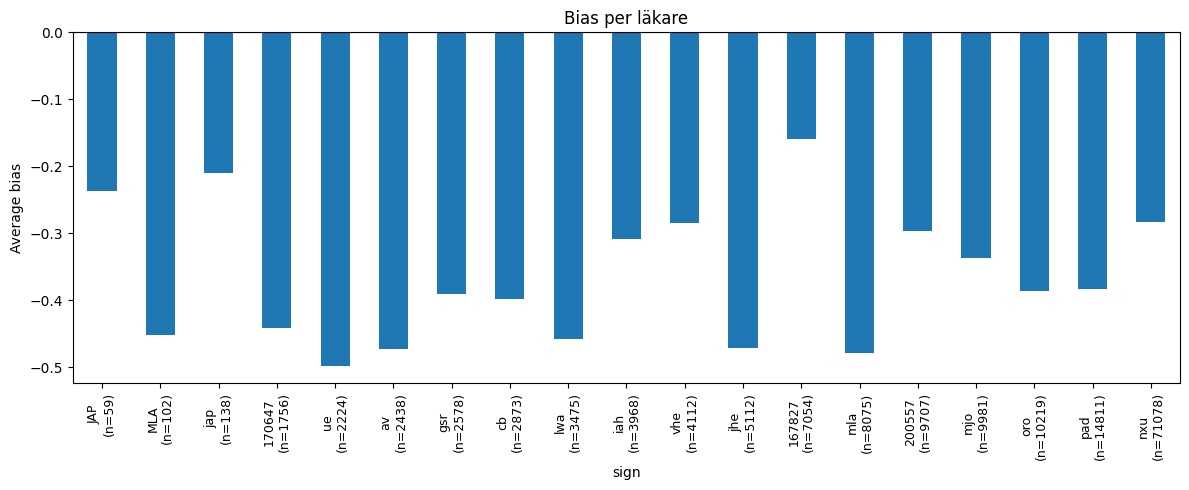

In [15]:

# Kör prediktioner på hela df
df = inflammation_model.predict(df)  # Lägger till df['inflammation']

# Lägg till true severity
from matplotlib import pyplot as plt

from networks.inflammation_network import to_severity

df['severity'] = df['inflammation_comment'].apply(to_severity)

# Analys
result = df[df['severity'].notna() & df['inflammation'].notna()].copy()
result['error'] = result['inflammation'] - result['severity']

summary = pd.DataFrame({
    'antal': result.groupby('sign').size(),
    'bias':  result.groupby('sign')['error'].mean()
}).sort_values('antal', ascending=False)

summary = summary[summary['antal'] > 50]
summary_sorted = summary.sort_values('antal')

labels = [f"{sign}\n(n={int(antal)})" for sign, antal in zip(summary_sorted.index, summary_sorted['antal'])]
summary_sorted['bias'].plot(kind='bar', figsize=(12, 5))
plt.xticks(range(len(labels)), labels, fontsize=9)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Average bias")
plt.title("Bias per läkare")
plt.tight_layout()
plt.show()

In [7]:
print(summary['bias'].describe())
print(summary['antal'].sum())
print(len(result))
print(result['error'].mean())

count    19.000000
mean     -0.365317
std       0.100627
min      -0.497752
25%      -0.454411
50%      -0.385458
75%      -0.290271
max      -0.159059
Name: bias, dtype: float64
159760
159814
-0.32938290763012
